# Set WD to Root

In [1]:
# Resolve the repository from this notebook's directory or the repository root.
from pathlib import Path
import os
import sys
_start = Path.cwd().resolve()
repo_root = next(p for p in (_start, *_start.parents) if (p / "src" / "weed_ca.py").is_file())
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pathlib import Path
import os

repo_root = Path.cwd().resolve()
os.chdir(repo_root)

print(Path.cwd())

d:\1_Document\A-02_Notebooks\1_UWA_Learning_Archive\02_Units\Y1S2_CITS4403 - Computational Modelling\Project\Repo


# Test Weed Index Initialize

In [2]:
from utils.data_loader import load_locality_data
import utils.weed_simulation_tools as wst

In [3]:
localities = load_locality_data()

metro = localities[
    localities["postcode"].astype(int).between(6000,6199)
].copy()

metro['weed_index'] = wst.weed_index_initialize(density=metro['population_density_km2'],
                                            pressure_coef=0.05,
                                            w_min=0.05,
                                            w_max=1)


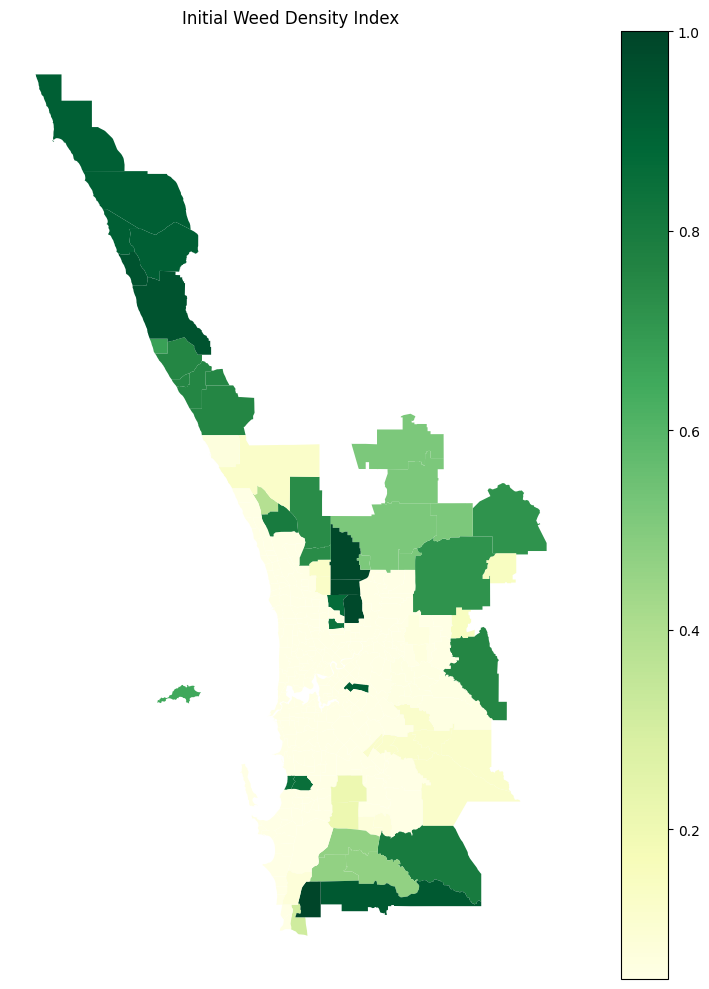

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

metro.plot(
    column="weed_index",
    cmap="YlGn",
    legend=True,
    ax=ax,
    edgecolor="none"
)

ax.set_title("Initial Weed Density Index")
ax.set_axis_off()

plt.tight_layout()
plt.show()

# Initialize Grid

In [5]:
import utils.weed_simulation_tools as wst
import numpy as np

In [30]:
weed_grid, valid_mask, transform = wst.polygon_to_grid(
    metro,
    cell_size=1000
)

print(weed_grid.shape)
print(np.nanmin(weed_grid))
print(np.nanmax(weed_grid))

(203, 124)
0.05
1.0


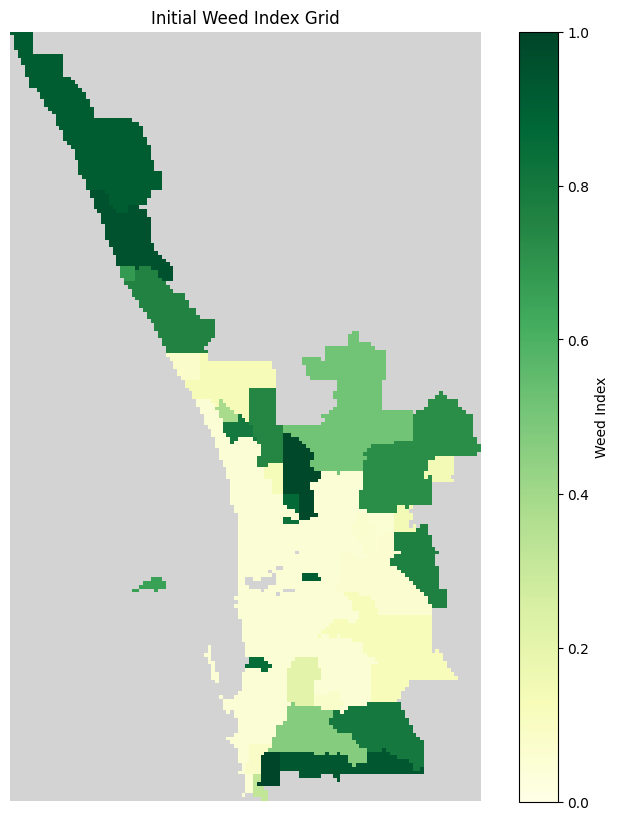

In [31]:
import matplotlib.pyplot as plt

cmap = plt.cm.YlGn.copy()
cmap.set_bad("lightgray")

plt.figure(figsize=(10, 10))

plt.imshow(
    weed_grid,
    cmap=cmap,
    vmin=0,
    vmax=1
)

plt.colorbar(label="Weed Index")

plt.title("Initial Weed Index Grid")
plt.axis("off")

plt.show()

# Test Weed CA Class

In [63]:
import importlib
import src.weed_ca

importlib.reload(src.weed_ca)

weedca = src.weed_ca.WeedCA.polygon_to_weedca(metro, 
                                                  pressure_coef=0.05,
                                                  cell_size=500,
                                                  growth_rate=0.02,
                                                  diffusion_rate=0.01)

modes = ['growth', 'diffusion']
weedca.animate(frames=108, fps=20, modes=modes)

In [38]:
(1+0.02)**54

2.9134614441402884

In [64]:
def simple_removal(weed_grid, mask):
    weed_grid[~mask] = 0
    diff = weed_grid * 0.001
    cost = np.sum(diff * 200)

    return diff, cost

weedca.register_policy(simple_removal)

In [66]:
modes = ['growth', 'diffusion', 'removal']
weedca.animate(frames=108, fps=20, modes=modes)